# Simple Energy Balance Model (EBM)
### Solar Geoengineering & CO₂ Forcing

The model integrates the zero-dimensional EBM:

$$C \frac{dT}{dt} = S\bigl(1 - \alpha(t)\bigr) - (a + bT) + F(t)$$

| Symbol | Meaning | Units |
|--------|---------|-------|
| $C$ | Thermal inertia (ocean mixed-layer heat capacity) | W·yr/m²/°C |
| $T$ | Global mean surface temperature | °C |
| $S$ | Mean insolation ($S_0 / 4$) | W/m² |
| $\alpha(t)$ | Planetary albedo — increased by SAI | — |
| $a + bT$ | Outgoing longwave radiation (Budyko linearization) | W/m² |
| $F(t)$ | CO₂ radiative forcing | W/m² |

**SAI** raises $\alpha(t)$ to offset $F(t)$; both are time-varying. The **energy imbalance** $Q = C\,dT/dt$ tracks how heat uptake changes under each scenario.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import ipywidgets as widgets
from ipywidgets import interact, FloatSlider, IntSlider, Dropdown
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

In [2]:
# ── Physical constants ───────────────────────────────────────────────────────
S0     = 1361.0   # Solar constant [W/m²]
S      = S0 / 4   # Sphere-averaged mean insolation [W/m²]

# ── Pre-industrial baseline (1850) ───────────────────────────────────────────
alpha0 = 0.30     # Planetary albedo
T0     = 288.15   # Surface temperature [K]  (≈ 15°C)

# ── OLR linearization: OLR = a + b·T  (Budyko 1969) ────────────────────────
b = 2.09          # OLR slope [W/m²/K]
a = S * (1 - alpha0) - b * T0   # Intercept tuned so T_eq = T0 exactly

# ── Default thermal inertia (~70 m ocean mixed layer) ───────────────────────
C_DEFAULT = 8.0   # [W·yr/m²/K]

print(f"OLR: a = {a:.3f} W/m², b = {b} W/m²/K")
print(f"Equilibrium check  →  T_eq = {(S*(1-alpha0) - a)/b:.4f} K  (target: {T0} K)")
print(f"Absorbed solar     →  {S*(1-alpha0):.2f} W/m²")
print(f"OLR at T0          →  {a + b*T0:.2f} W/m²")

OLR: a = -364.058 W/m², b = 2.09 W/m²/K
Equilibrium check  →  T_eq = 288.1500 K  (target: 288.15 K)
Absorbed solar     →  238.17 W/m²
OLR at T0          →  238.17 W/m²


In [3]:
def co2_forcing(t, scenario='rcp45'):
    """
    CO₂ radiative forcing relative to pre-industrial [W/m²].

    Historical (1850–2023): linear ramp 0 → 2.3 W/m² for all scenarios.
    Post-2023 projections follow IPCC RCP pathways.
      'none'  : no forcing at any time (pre-industrial control)
      'rcp26' : strong mitigation, peaks ~3.0 then declines
      'rcp45' : moderate stabilisation at 4.5 W/m²
      'rcp85' : high-emission pathway to 8.5 W/m²
    """
    if scenario == 'none':
        return 0.0

    # Historical ramp (identical for all scenarios)
    if t <= 2023:
        return float(np.interp(t, [1850, 2023], [0.0, 2.3]))

    # Post-2023 scenario divergence
    # projections = {
    #     'rcp26': ([2023, 2040, 2100, 2150], [2.3, 3.0, 2.6, 2.4]),
    #     'rcp45': ([2023, 2100, 2150],        [2.3, 4.5, 4.5]),
    #     'rcp85': ([2023, 2100, 2150],        [2.3, 8.5, 8.5]),
    # }
    projections = {
        'rcp26': ([2023, 2040, 2100, 2150], [2.3, 3.0, 2.6, 1.0]),
        'rcp45': ([2023, 2100, 2150],        [2.3, 4.5, 6.5]),
        'rcp85': ([2023, 2100, 2150],        [2.3, 8.5, 12.5]),
    }
    ts, Fs = projections[scenario]
    return float(np.interp(t, ts, Fs))


def sai_delta_alpha(t, d_alpha=0.0, start_year=2030, ramp_years=10):
    """
    Additional albedo from stratospheric aerosol injection (SAI) [dimensionless].

    Ramps linearly from start_year over ramp_years, then holds indefinitely.
    d_alpha = 0.01 offsets roughly -3.4 W/m² of solar forcing.
    """
    if d_alpha == 0.0 or t < start_year:
        return 0.0
    ramp_end = start_year + ramp_years
    if t < ramp_end:
        return d_alpha * (t - start_year) / ramp_years
    return d_alpha


def energy_imbalance(t, T, d_alpha=0.0, scenario='rcp45', sai_start=2030, sai_ramp=10):
    """Net energy flux Q = S(1−α) − OLR + F  [W/m²]  (= C·dT/dt)"""
    alpha = alpha0 + sai_delta_alpha(t, d_alpha=d_alpha, start_year=sai_start, ramp_years=sai_ramp)
    F     = co2_forcing(t, scenario=scenario)
    return S * (1 - alpha) - (a + b * T) + F

In [4]:
def run_ebm(C=C_DEFAULT, scenario='rcp45', d_alpha=0.0,
            sai_start=2030, sai_ramp=10, t_span=(1850, 2150), n_pts=2400):
    """
    Integrate C·dT/dt = Q(t, T) using RK45.

    Returns
    -------
    t : ndarray  — time [years]
    T : ndarray  — temperature [°C]
    Q : ndarray  — energy imbalance [W/m²]  (= C·dT/dt)
    """
    kw = dict(d_alpha=d_alpha, scenario=scenario, sai_start=sai_start, sai_ramp=sai_ramp)

    def rhs(t, y):
        return [energy_imbalance(t, y[0], **kw) / C]

    t_eval = np.linspace(*t_span, n_pts)
    sol = solve_ivp(rhs, t_span, [T0], t_eval=t_eval, method='RK45', rtol=1e-8, atol=1e-10)

    Q = np.array([energy_imbalance(ti, Ti, **kw) for ti, Ti in zip(sol.t, sol.y[0])])
    return sol.t, sol.y[0], Q

## Scenario Comparison
**Left column** — CO₂ forcing only (no SAI), across four RCP pathways.  
**Right column** — SAI at varying deployment levels under RCP 4.5.  
Top row: temperature trajectory. Bottom row: energy imbalance $Q = C\,dT/dt$.

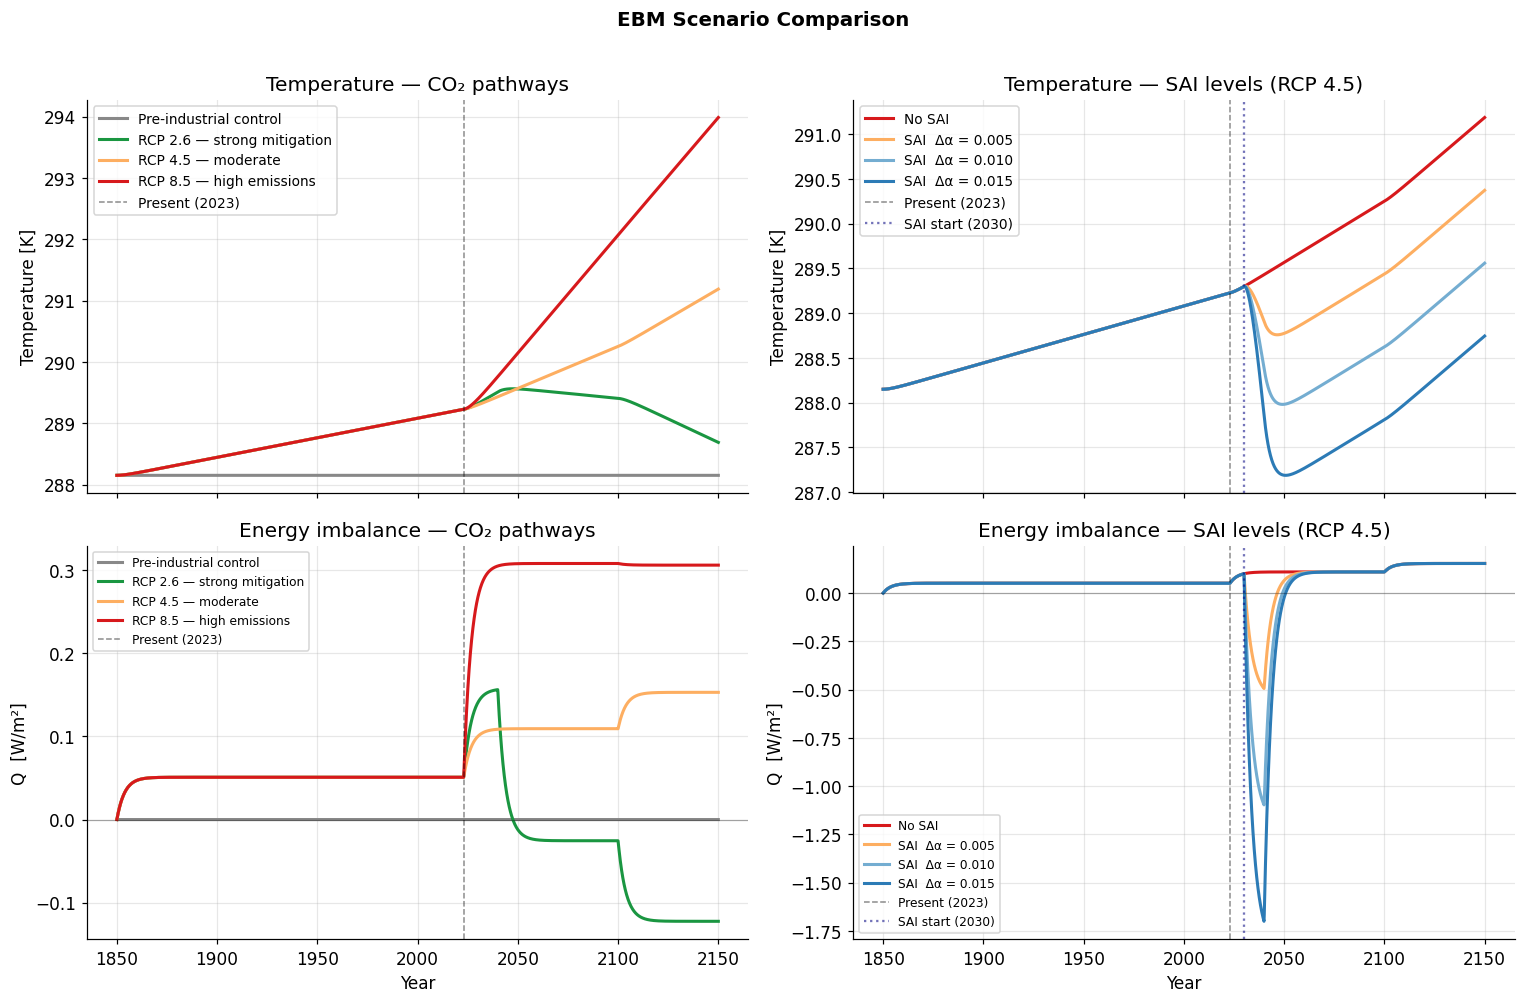

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
fig.suptitle('EBM Scenario Comparison', fontsize=13, fontweight='bold', y=1.01)

# ── CO₂ scenarios (no SAI) ───────────────────────────────────────────────────
co2_cases = [
    ('none',  'Pre-industrial control',       '#888888'),
    ('rcp26', 'RCP 2.6 — strong mitigation',  '#1a9641'),
    ('rcp45', 'RCP 4.5 — moderate',           '#fdae61'),
    ('rcp85', 'RCP 8.5 — high emissions',     '#d7191c'),
]
for scen, label, color in co2_cases:
    t, T, Q = run_ebm(scenario=scen, d_alpha=0.0)
    axes[0, 0].plot(t, T, color=color, lw=2, label=label)
    axes[1, 0].plot(t, Q, color=color, lw=2, label=label)

# ── SAI levels under RCP 4.5 ────────────────────────────────────────────────
sai_cases = [
    (0.000, 'No SAI',          '#d7191c'),
    (0.005, 'SAI  Δα = 0.005', '#fdae61'),
    (0.010, 'SAI  Δα = 0.010', '#74add1'),
    (0.015, 'SAI  Δα = 0.015', '#2c7bb6'),
]
for da, label, color in sai_cases:
    t, T, Q = run_ebm(scenario='rcp45', d_alpha=da)
    axes[0, 1].plot(t, T, color=color, lw=2, label=label)
    axes[1, 1].plot(t, Q, color=color, lw=2, label=label)

# ── Annotations ─────────────────────────────────────────────────────────────
for ax in axes.flat:
    ax.axvline(2023, color='k',    ls='--', lw=1,   alpha=0.45, label='Present (2023)')
for ax in axes[:, 1]:
    ax.axvline(2030, color='navy', ls=':',  lw=1.5, alpha=0.55, label='SAI start (2030)')
for ax in axes[1, :]:
    ax.axhline(0, color='k', ls='-', lw=0.8, alpha=0.3)

axes[0, 0].set(title='Temperature — CO₂ pathways',              ylabel='Temperature [K]')
axes[1, 0].set(title='Energy imbalance — CO₂ pathways',         ylabel='Q  [W/m²]', xlabel='Year')
axes[0, 1].set(title='Temperature — SAI levels (RCP 4.5)',       ylabel='Temperature [K]')
axes[1, 1].set(title='Energy imbalance — SAI levels (RCP 4.5)', ylabel='Q  [W/m²]', xlabel='Year')

for ax in axes[0, :]:
    ax.legend(fontsize=9)
for ax in axes[1, :]:
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## Interactive Exploration

Use the sliders to explore how changing CO₂ pathway, SAI deployment, thermal inertia, and timing affect the temperature trajectory and energy imbalance in real time.

The **forcing breakdown** (right panel) decomposes $Q$ into its CO₂ and SAI components so you can see when and how much each term contributes.

In [6]:
def plot_ebm(C, scenario, d_alpha, sai_start, sai_ramp):
    t_base, T_base, Q_base = run_ebm(C=C, scenario=scenario, d_alpha=0.0)
    t_sai,  T_sai,  Q_sai  = run_ebm(C=C, scenario=scenario, d_alpha=d_alpha,
                                       sai_start=sai_start, sai_ramp=sai_ramp)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(f'EBM  |  {scenario.upper()}  |  C = {C:.1f} W·yr/m²/K', fontsize=12, fontweight='bold')

    # — Temperature ————————————————————————————————————————————————————————
    axes[0].plot(t_base, T_base, color='#d7191c', lw=2, label='No SAI')
    axes[0].plot(t_sai,  T_sai,  color='#2c7bb6', lw=2, label=f'SAI  Δα = {d_alpha:.3f}')
    axes[0].fill_between(t_sai, T_base, T_sai,
                         where=(T_sai < T_base), alpha=0.15, color='#2c7bb6', label='Cooling offset')
    axes[0].set(title='Temperature', ylabel='T [K]', xlabel='Year')

    # — Energy imbalance ——————————————————————————————————————————————————
    axes[1].plot(t_base, Q_base, color='#d7191c', lw=2, label='No SAI')
    axes[1].plot(t_sai,  Q_sai,  color='#2c7bb6', lw=2, label=f'SAI  Δα = {d_alpha:.3f}')
    axes[1].axhline(0, color='k', lw=0.8, alpha=0.4)
    axes[1].set(title='Energy Imbalance  Q = C·dT/dt', ylabel='W/m²', xlabel='Year')

    # — Energy balance decomposition ——————————————————————————————————————
    # Q = F_CO2  +  F_SAI  +  OLR_feedback
    #   = F(t)   + (−S·Δα) + (−b·(T−T0))
    # All three terms sum to Q (shown as black line, matching center panel).
    # OLR feedback is the missing term that explains why Q can be negative
    # even when the radiative forcings alone (F_CO2 + F_SAI) are positive.
    F_co2_arr  = np.array([co2_forcing(ti, scenario=scenario) for ti in t_sai])
    F_sai_arr  = np.array([-S * sai_delta_alpha(ti, d_alpha=d_alpha,
                                                  start_year=sai_start, ramp_years=sai_ramp)
                            for ti in t_sai])
    OLR_fb_arr = -(b * (T_sai - T0))   # negative when T > T0; drives Q negative during overshoot

    Q_decomp   = F_co2_arr + F_sai_arr + OLR_fb_arr  # must equal Q_sai

    axes[2].fill_between(t_sai, F_co2_arr,  alpha=0.35, color='#d7191c', label='CO₂ forcing  F(t)')
    axes[2].fill_between(t_sai, F_sai_arr,  alpha=0.35, color='#2c7bb6', label='SAI forcing  −S·Δα')
    axes[2].fill_between(t_sai, OLR_fb_arr, alpha=0.35, color='#fdae61', label='OLR feedback  −b·(T−T₀)')
    axes[2].plot(t_sai, Q_decomp, 'k-', lw=1.8, label='Q  (= center panel)')
    axes[2].axhline(0, color='k', lw=0.8, alpha=0.4)
    axes[2].set(title='Energy Balance Decomposition\nQ = F_CO₂ + F_SAI + OLR feedback',
                ylabel='W/m²', xlabel='Year')

    for ax in axes:
        ax.axvline(2023, color='k',    ls='--', lw=1,   alpha=0.4)
        if d_alpha > 0:
            ax.axvline(sai_start, color='navy', ls=':', lw=1.5, alpha=0.5)
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()


interact(
    plot_ebm,
    C          = FloatSlider(value=8.0,  min=2.0,  max=20.0, step=0.5,   description='C [W·yr/m²/K]', style={'description_width':'initial'}),
    scenario   = Dropdown(options=['none','rcp26','rcp45','rcp85'], value='rcp45', description='CO₂ scenario'),
    d_alpha    = FloatSlider(value=0.0,  min=0.0,  max=0.025, step=0.001, description='SAI  Δα',       style={'description_width':'initial'}, readout_format='.3f'),
    sai_start  = IntSlider(  value=2030, min=2025, max=2080,  step=5,     description='SAI start year', style={'description_width':'initial'}),
    sai_ramp   = IntSlider(  value=10,   min=1,    max=30,    step=1,     description='Ramp-up years',  style={'description_width':'initial'}),
);

interactive(children=(FloatSlider(value=8.0, description='C [W·yr/m²/K]', max=20.0, min=2.0, step=0.5, style=S…

## Thermal Inertia Sensitivity

$C$ sets how quickly the system responds to forcing — larger $C$ (deeper ocean coupling) slows warming but also slows the response to SAI. Below: temperature and energy imbalance for five values of $C$ under RCP 4.5 with a moderate SAI deployment (Δα = 0.010).

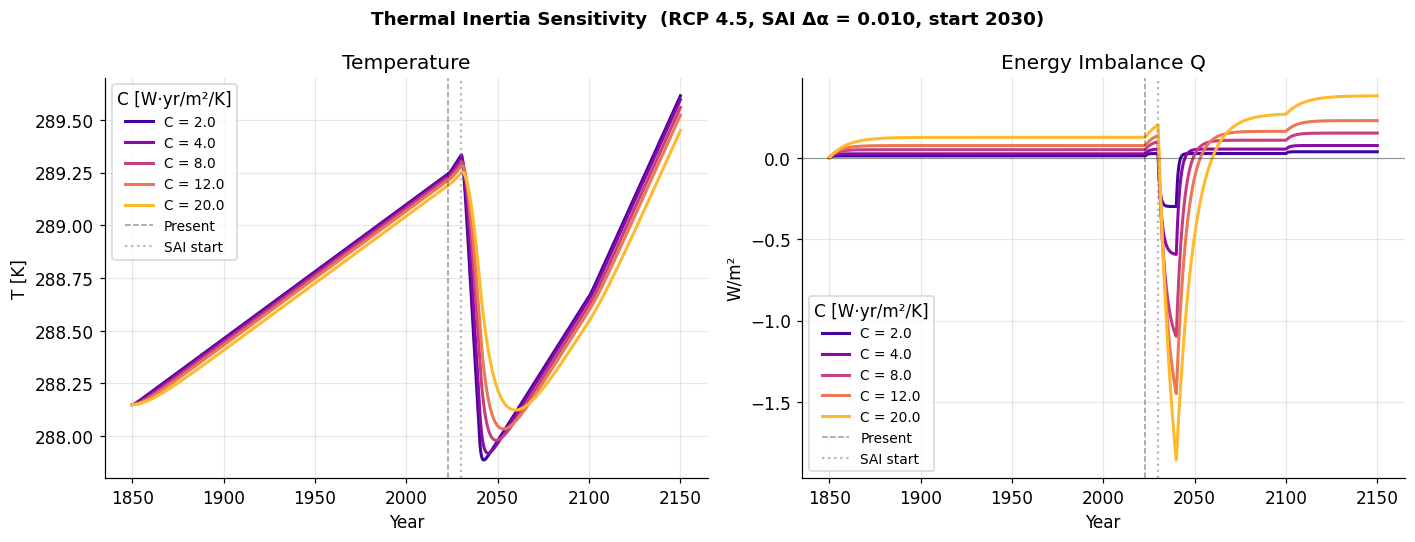

In [7]:
C_values = [2.0, 4.0, 8.0, 12.0, 20.0]
colors   = plt.cm.plasma(np.linspace(0.1, 0.85, len(C_values)))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Thermal Inertia Sensitivity  (RCP 4.5, SAI Δα = 0.010, start 2030)',
             fontsize=12, fontweight='bold')

for C_val, color in zip(C_values, colors):
    t, T, Q = run_ebm(C=C_val, scenario='rcp45', d_alpha=0.010)
    lbl = f'C = {C_val}'
    axes[0].plot(t, T, color=color, lw=2, label=lbl)
    axes[1].plot(t, Q, color=color, lw=2, label=lbl)

for ax in axes:
    ax.axvline(2023, color='k',    ls='--', lw=1,   alpha=0.4,  label='Present')
    ax.axvline(2030, color='gray', ls=':',  lw=1.5, alpha=0.55, label='SAI start')

axes[1].axhline(0, color='k', lw=0.8, alpha=0.35)

axes[0].set(title='Temperature',        ylabel='T [K]',   xlabel='Year')
axes[1].set(title='Energy Imbalance Q', ylabel='W/m²',    xlabel='Year')

for ax in axes:
    ax.legend(title='C [W·yr/m²/K]', fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
# ── SAI with post-ramp slope ──────────────────────────────────────────────────
# Redefines the sai_delta_alpha → energy_imbalance → run_ebm → plot_ebm chain
# to thread a d_alpha_slope parameter (increase in da per year after ramp).

def sai_delta_alpha(t, d_alpha=0.0, start_year=2030, ramp_years=10, d_alpha_slope=0.0):
    """
    Additional albedo from SAI.

    Phase 1 – pre-deployment  [t < start_year]:              0
    Phase 2 – ramp-up         [start_year, start_year+ramp): linear 0 → d_alpha
    Phase 3 – post-ramp       [t >= start_year+ramp):        d_alpha + d_alpha_slope*(t-ramp_end)
    """
    if d_alpha == 0.0 or t < start_year:
        return 0.0
    ramp_end = start_year + ramp_years
    if t < ramp_end:
        return d_alpha * (t - start_year) / ramp_years
    return d_alpha + d_alpha_slope * (t - ramp_end)


def energy_imbalance(t, T, d_alpha=0.0, scenario='rcp45',
                     sai_start=2030, sai_ramp=10, d_alpha_slope=0.0):
    alpha = alpha0 + sai_delta_alpha(t, d_alpha=d_alpha, start_year=sai_start,
                                     ramp_years=sai_ramp, d_alpha_slope=d_alpha_slope)
    F = co2_forcing(t, scenario=scenario)
    return S * (1 - alpha) - (a + b * T) + F


def run_ebm(C=C_DEFAULT, scenario='rcp45', d_alpha=0.0,
            sai_start=2030, sai_ramp=10, d_alpha_slope=0.0,
            t_span=(1850, 2150), n_pts=2400):
    kw = dict(d_alpha=d_alpha, scenario=scenario, sai_start=sai_start,
              sai_ramp=sai_ramp, d_alpha_slope=d_alpha_slope)

    def rhs(t, y):
        return [energy_imbalance(t, y[0], **kw) / C]

    t_eval = np.linspace(*t_span, n_pts)
    sol = solve_ivp(rhs, t_span, [T0], t_eval=t_eval, method='RK45', rtol=1e-8, atol=1e-10)
    Q = np.array([energy_imbalance(ti, Ti, **kw) for ti, Ti in zip(sol.t, sol.y[0])])
    return sol.t, sol.y[0], Q


def plot_ebm(C, scenario, d_alpha, sai_start, sai_ramp, d_alpha_slope):
    t_base, T_base, Q_base = run_ebm(C=C, scenario=scenario, d_alpha=0.0)
    t_sai,  T_sai,  Q_sai  = run_ebm(C=C, scenario=scenario, d_alpha=d_alpha,
                                       sai_start=sai_start, sai_ramp=sai_ramp,
                                       d_alpha_slope=d_alpha_slope)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(f'EBM  |  {scenario.upper()}  |  C = {C:.1f} W·yr/m²/K', fontsize=12, fontweight='bold')

    # — Temperature ————————————————————————————————————————————————————————
    axes[0].plot(t_base, T_base, color='#d7191c', lw=2, label='No SAI')
    axes[0].plot(t_sai,  T_sai,  color='#2c7bb6', lw=2,
                 label=f'SAI  Δα={d_alpha:.3f}, slope={d_alpha_slope:.4f}/yr')
    axes[0].fill_between(t_sai, T_base, T_sai,
                         where=(T_sai < T_base), alpha=0.15, color='#2c7bb6', label='Cooling offset')
    axes[0].set(title='Temperature', ylabel='T [K]', xlabel='Year')

    # — Energy imbalance ——————————————————————————————————————————————————
    axes[1].plot(t_base, Q_base, color='#d7191c', lw=2, label='No SAI')
    axes[1].plot(t_sai,  Q_sai,  color='#2c7bb6', lw=2,
                 label=f'SAI  Δα={d_alpha:.3f}, slope={d_alpha_slope:.4f}/yr')
    axes[1].axhline(0, color='k', lw=0.8, alpha=0.4)
    axes[1].set(title='Energy Imbalance  Q = C·dT/dt', ylabel='W/m²', xlabel='Year')

    # — Energy balance decomposition ——————————————————————————————————————
    F_co2_arr  = np.array([co2_forcing(ti, scenario=scenario) for ti in t_sai])
    F_sai_arr  = np.array([-S * sai_delta_alpha(ti, d_alpha=d_alpha, start_year=sai_start,
                                                  ramp_years=sai_ramp, d_alpha_slope=d_alpha_slope)
                            for ti in t_sai])
    OLR_fb_arr = -(b * (T_sai - T0))
    Q_decomp   = F_co2_arr + F_sai_arr + OLR_fb_arr

    axes[2].fill_between(t_sai, F_co2_arr,  alpha=0.35, color='#d7191c', label='CO₂ forcing  F(t)')
    axes[2].fill_between(t_sai, F_sai_arr,  alpha=0.35, color='#2c7bb6', label='SAI forcing  −S·Δα(t)')
    axes[2].fill_between(t_sai, OLR_fb_arr, alpha=0.35, color='#fdae61', label='OLR feedback  −b·(T−T₀)')
    axes[2].plot(t_sai, Q_decomp, 'k-', lw=1.8, label='Q  (= center panel)')
    axes[2].axhline(0, color='k', lw=0.8, alpha=0.4)
    axes[2].set(title='Energy Balance Decomposition\nQ = F_CO₂ + F_SAI + OLR feedback',
                ylabel='W/m²', xlabel='Year')

    for ax in axes:
        ax.axvline(2023, color='k', ls='--', lw=1, alpha=0.4)
        if d_alpha > 0:
            ax.axvline(sai_start,            color='navy',      ls=':', lw=1.5, alpha=0.5)
            ax.axvline(sai_start + sai_ramp, color='steelblue', ls=':', lw=1.0, alpha=0.5)
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()


interact(
    plot_ebm,
    C            = FloatSlider(value=8.0,  min=2.0,  max=20.0,  step=0.5,    description='C [W·yr/m²/K]',        style={'description_width': 'initial'}),
    scenario     = Dropdown(options=['none', 'rcp26', 'rcp45', 'rcp85'], value='rcp45', description='CO₂ scenario'),
    d_alpha      = FloatSlider(value=0.0,  min=0.0,  max=0.025, step=0.001,  description='SAI  Δα',               style={'description_width': 'initial'}, readout_format='.3f'),
    sai_start    = IntSlider(  value=2030, min=2025, max=2080,  step=5,      description='SAI start year',        style={'description_width': 'initial'}),
    sai_ramp     = IntSlider(  value=10,   min=1,    max=30,    step=1,      description='Ramp-up years',         style={'description_width': 'initial'}),
    d_alpha_slope= FloatSlider(value=0.0,  min=0.0,  max=0.0005, step=0.00001, description='Post-ramp slope (da/yr)', style={'description_width': 'initial'}, readout_format='.4f'),
);

interactive(children=(FloatSlider(value=8.0, description='C [W·yr/m²/K]', max=20.0, min=2.0, step=0.5, style=S…